# ЛР №3. "Обучение с учителем. Задача классификации"

## Импорт

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('../data/Classification_smoke_detectors_filtered.csv')

In [ ]:
X = df.drop(columns=['Fire Alarm'])
y = df['Fire Alarm']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777, stratify=y)

In [84]:
num_classes = y.nunique()
num_classes

2

Классификация бинарная

## Балансировка классов

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

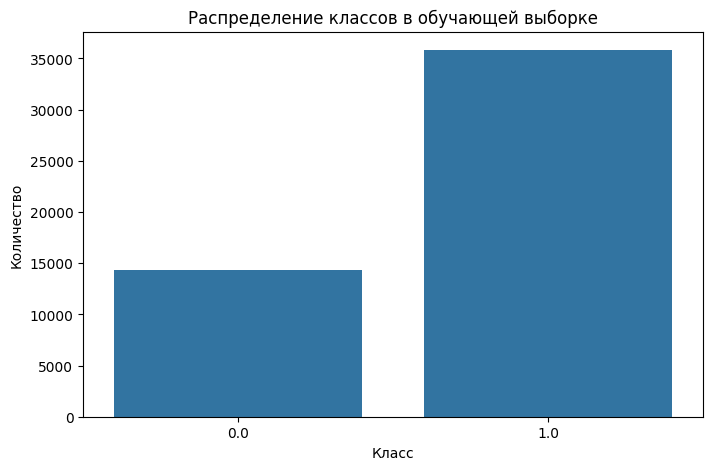

In [86]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train)
plt.title('Распределение классов в обучающей выборке')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()

In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=777)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"До балансировки: {y_train.value_counts().to_dict()}")
print(f"После балансировки: {y_train_balanced.value_counts().to_dict()}")

До балансировки: {1.0: 35806, 0.0: 14298}
После балансировки: {1.0: 35806, 0.0: 35806}


## Обучение моделей

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression())]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=5))]),
    "Naive Bayes": Pipeline([("scaler", StandardScaler()), ("clf", GaussianNB())]),
    "SVM (RBF Kernel)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel='rbf'))]),
    "SVM (Sigmoid Kernel)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel='sigmoid'))]),
    "SVM (Polynomial Kernel)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel='poly', degree=3))]),
    "SVM (Linear Kernel)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel='linear'))]),
}

In [89]:
import joblib
import os

preloadModel = True

for name, model in models.items():
    model_path = f'../models/{name}.pkl'
    if preloadModel and os.path.exists(model_path):
        loaded_model = joblib.load(f'../models/{name}.pkl')
        y_pred = loaded_model.predict(X_test)
        print(f"{name}: {accuracy_score(y_test, y_pred):.4f}")
        continue

    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    joblib.dump(model, f'../models/{name}.pkl')
    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.9835
KNN: 0.9995
Naive Bayes: 0.8202
SVM (RBF Kernel): 0.9995
SVM (Sigmoid Kernel): 0.8023
SVM (Polynomial Kernel): 0.9995
SVM (Linear Kernel): 0.9927


## Подбор гиперпараметров

In [ ]:
import optuna
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)

kf = KFold(n_splits=5, shuffle=True, random_state=777)

**Линейная регрессия**

In [91]:
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10]
}

best_lr = GridSearchCV(models["Logistic Regression"], param_grid_lr, cv=kf, scoring='accuracy')

best_lr.fit(X_train_balanced, y_train_balanced)
y_pred_lr = best_lr.predict(X_test)
accuracy_score(y_test, y_pred_lr)

0.9801213475969982

**KNN**

In [92]:
param_dist_knn = {
    'clf__n_neighbors': range(1, 21),
    'clf__weights': ['uniform', 'distance']
}

best_knn = RandomizedSearchCV(models["KNN"], param_dist_knn, n_iter=10, cv=kf, scoring='accuracy', random_state=777)

best_knn.fit(X_train_balanced, y_train_balanced)
y_pred_knn = best_knn.predict(X_test)
accuracy_score(y_test, y_pred_knn)

0.9996008302730321

**Наивный Байес**

In [93]:
def objective_nb(trial, X, y):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-10, 1e-7, log=True)
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", GaussianNB(var_smoothing=var_smoothing))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study_nb = optuna.create_study(direction="maximize")
study_nb.optimize(lambda trial: objective_nb(trial, X_train_balanced, y_train_balanced), n_trials=5)
study_nb.best_value

[I 2026-04-11 22:16:08,580] A new study created in memory with name: no-name-51a6823f-f71f-4ba7-9d41-a3488bbe61fc
[I 2026-04-11 22:16:08,653] Trial 0 finished with value: 0.7736972406223082 and parameters: {'var_smoothing': 1.0890811250927125e-08}. Best is trial 0 with value: 0.7736972406223082.
[I 2026-04-11 22:16:08,707] Trial 1 finished with value: 0.7736972406223082 and parameters: {'var_smoothing': 7.75139834073539e-08}. Best is trial 0 with value: 0.7736972406223082.
[I 2026-04-11 22:16:08,761] Trial 2 finished with value: 0.7736972406223082 and parameters: {'var_smoothing': 2.271760158628099e-10}. Best is trial 0 with value: 0.7736972406223082.
[I 2026-04-11 22:16:08,814] Trial 3 finished with value: 0.7736972406223082 and parameters: {'var_smoothing': 5.5611979015418104e-09}. Best is trial 0 with value: 0.7736972406223082.
[I 2026-04-11 22:16:08,868] Trial 4 finished with value: 0.7736972406223082 and parameters: {'var_smoothing': 1.1943566029998927e-08}. Best is trial 0 with v

0.7736972406223082

**SVM RBF**

In [94]:
def objective_svm_rbf(trial, X, y):
    c = trial.suggest_float('C', 0.1, 10, log=True)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", SVC(kernel='rbf', C=c, gamma=gamma))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study_svm_rbf = optuna.create_study(direction="maximize")
study_svm_rbf.optimize(lambda trial: objective_svm_rbf(trial, X_train_balanced, y_train_balanced), n_trials=5)
study_svm_rbf.best_value

[I 2026-04-11 22:16:08,875] A new study created in memory with name: no-name-6f35dca4-42eb-4be8-a4e7-c851e7298e27
[I 2026-04-11 22:16:16,242] Trial 0 finished with value: 0.9995531408868406 and parameters: {'C': 1.3875228060669162, 'gamma': 'scale'}. Best is trial 0 with value: 0.9995531408868406.
[I 2026-04-11 22:16:23,377] Trial 1 finished with value: 0.9995391773317195 and parameters: {'C': 1.54268784639294, 'gamma': 'auto'}. Best is trial 0 with value: 0.9995531408868406.
[I 2026-04-11 22:16:37,297] Trial 2 finished with value: 0.9988688945118149 and parameters: {'C': 0.32126591404599425, 'gamma': 'scale'}. Best is trial 0 with value: 0.9995531408868406.
[I 2026-04-11 22:16:46,185] Trial 3 finished with value: 0.999539176356747 and parameters: {'C': 0.8978562123605917, 'gamma': 'auto'}. Best is trial 0 with value: 0.9995531408868406.
[I 2026-04-11 22:16:54,311] Trial 4 finished with value: 0.9995252118266533 and parameters: {'C': 1.086825094970619, 'gamma': 'scale'}. Best is trial 

0.9995531408868406

**SVM Sigmoid**

In [95]:
def objective_svm_sigmoid(trial, X, y):
    c = trial.suggest_float('C', 0.1, 10, log=True)
    coef0 = trial.suggest_float('coef0', 0.0, 1.0)
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", SVC(kernel='sigmoid', C=c, coef0=coef0))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study_sigmoid = optuna.create_study(direction="maximize")
study_sigmoid.optimize(lambda trial: objective_svm_sigmoid(trial, X_train_balanced, y_train_balanced), n_trials=5)
study_sigmoid.best_value

[I 2026-04-11 22:16:54,318] A new study created in memory with name: no-name-36a31590-5c20-4648-8d92-cb94bd2f93b5
[I 2026-04-11 22:18:07,658] Trial 0 finished with value: 0.744232818229075 and parameters: {'C': 1.3157484021197055, 'coef0': 0.9848478910512809}. Best is trial 0 with value: 0.744232818229075.
[I 2026-04-11 22:19:12,919] Trial 1 finished with value: 0.795578975823248 and parameters: {'C': 0.4705797931778512, 'coef0': 0.5522992527697104}. Best is trial 1 with value: 0.795578975823248.
[I 2026-04-11 22:20:21,566] Trial 2 finished with value: 0.7671200678448215 and parameters: {'C': 1.6190952496716364, 'coef0': 0.788282720082868}. Best is trial 1 with value: 0.795578975823248.
[I 2026-04-11 22:21:27,979] Trial 3 finished with value: 0.7778445081406933 and parameters: {'C': 0.6213909552602065, 'coef0': 0.7013690782555821}. Best is trial 1 with value: 0.795578975823248.
[I 2026-04-11 22:22:37,742] Trial 4 finished with value: 0.8170976654158452 and parameters: {'C': 8.581950597

0.8170976654158452

**SVM Polynomial**

In [96]:
def objective_svm_poly(trial, X, y):
    c = trial.suggest_float('C', 0.1, 10, log=True)
    degree = trial.suggest_int('degree', 2, 5)
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", SVC(kernel='poly', C=c, degree=degree))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study_svm_poly = optuna.create_study(direction="maximize")
study_svm_poly.optimize(lambda trial: objective_svm_poly(trial, X_train_balanced, y_train_balanced), n_trials=5)
study_svm_poly.best_value

[I 2026-04-11 22:22:37,749] A new study created in memory with name: no-name-2b990c1a-98fa-4a9c-b42d-6d8b5ac0a043
[I 2026-04-11 22:23:04,301] Trial 0 finished with value: 0.9875160347621739 and parameters: {'C': 0.22298371969480205, 'degree': 2}. Best is trial 0 with value: 0.9875160347621739.
[I 2026-04-11 22:23:41,909] Trial 1 finished with value: 0.972895603667 and parameters: {'C': 3.1949426118876567, 'degree': 5}. Best is trial 0 with value: 0.9875160347621739.
[I 2026-04-11 22:25:31,136] Trial 2 finished with value: 0.8997653660602719 and parameters: {'C': 0.11536704895650701, 'degree': 5}. Best is trial 0 with value: 0.9875160347621739.
[I 2026-04-11 22:25:59,242] Trial 3 finished with value: 0.9870971164088708 and parameters: {'C': 0.20280731470100122, 'degree': 2}. Best is trial 0 with value: 0.9875160347621739.
[I 2026-04-11 22:26:36,429] Trial 4 finished with value: 0.9835502213124039 and parameters: {'C': 0.11286478966738747, 'degree': 2}. Best is trial 0 with value: 0.9875

0.9875160347621739

**SVM Linear**

In [97]:
def objective_svm_linear(trial, X, y):
    c = trial.suggest_float('C', 0.1, 10, log=True)
    
    model = Pipeline([
        ("scaler", StandardScaler()), 
        ("clf", SVC(kernel='linear', C=c))
    ])
    return cross_val_score(model, X, y, cv=kf, scoring='accuracy').mean()

study_svm = optuna.create_study(direction="maximize")
study_svm.optimize(lambda trial: objective_svm_poly(trial, X_train_balanced, y_train_balanced), n_trials=5)
study_svm.best_value

[I 2026-04-11 22:26:36,436] A new study created in memory with name: no-name-ea7334af-6e5d-47dc-83c0-80cb80683ce3
[I 2026-04-11 22:26:43,978] Trial 0 finished with value: 0.9985896087848058 and parameters: {'C': 5.971565709897534, 'degree': 2}. Best is trial 0 with value: 0.9985896087848058.
[I 2026-04-11 22:26:52,852] Trial 1 finished with value: 0.9983382530929562 and parameters: {'C': 4.648783979245607, 'degree': 2}. Best is trial 0 with value: 0.9985896087848058.
[I 2026-04-11 22:27:27,296] Trial 2 finished with value: 0.9851142204086825 and parameters: {'C': 4.327679252953282, 'degree': 5}. Best is trial 0 with value: 0.9985896087848058.
[I 2026-04-11 22:28:13,486] Trial 3 finished with value: 0.9406523694564811 and parameters: {'C': 1.50952729145626, 'degree': 5}. Best is trial 0 with value: 0.9985896087848058.
[I 2026-04-11 22:28:24,601] Trial 4 finished with value: 0.9974445426664168 and parameters: {'C': 2.3987815353326107, 'degree': 2}. Best is trial 0 with value: 0.998589608

0.9985896087848058

## Оценка моделей при помощи метрик классификации

In [98]:
from sklearn.metrics import RocCurveDisplay

**Линейная регрессия**

In [99]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.94      0.99      0.97      3575
         1.0       1.00      0.98      0.99      8951

    accuracy                           0.98     12526
   macro avg       0.97      0.98      0.98     12526
weighted avg       0.98      0.98      0.98     12526



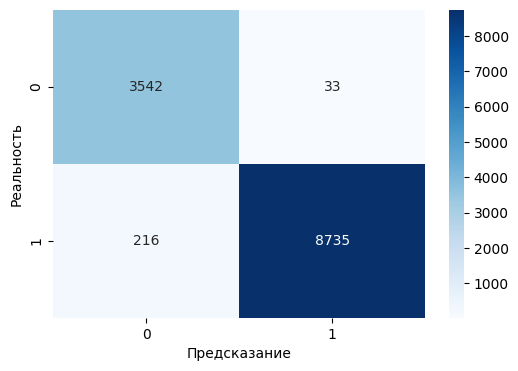

In [100]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

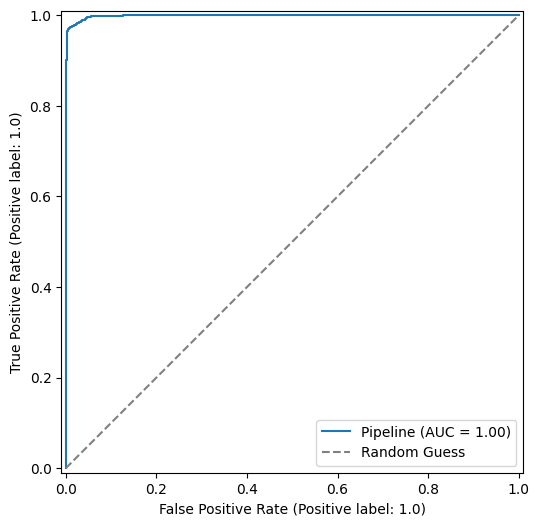

In [101]:
fig, ax = plt.subplots(figsize=(8, 6))
models["Logistic Regression"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["Logistic Regression"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

**KNN**

In [102]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3575
         1.0       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



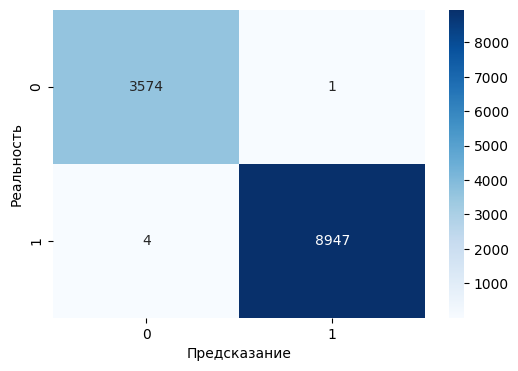

In [103]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

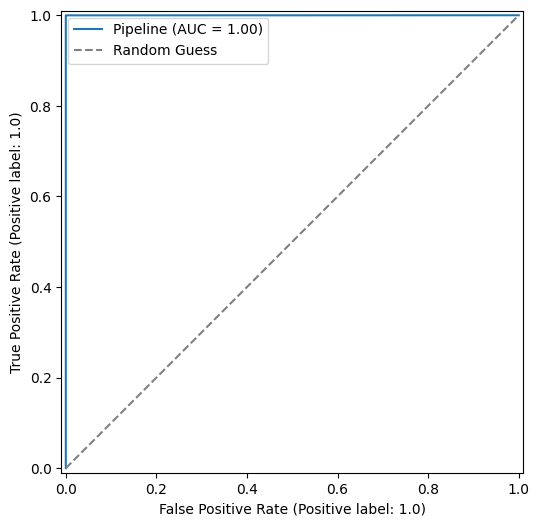

In [104]:
fig, ax = plt.subplots(figsize=(8, 6))
models["KNN"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["KNN"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

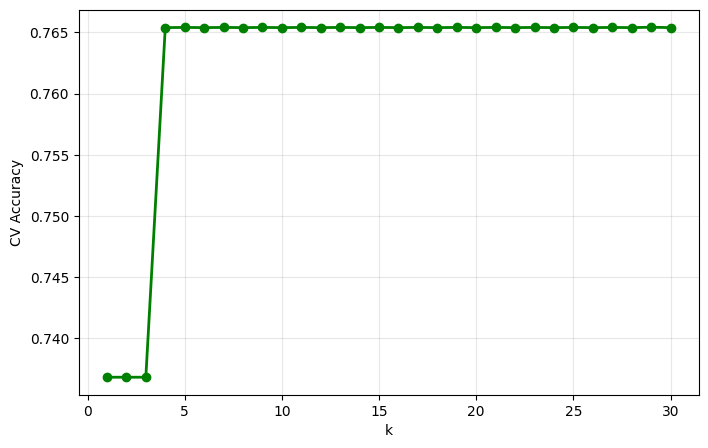

In [105]:
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='o', color='green', linewidth=2)
plt.xlabel('k')
plt.ylabel('CV Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

best_k_cv = k_range[np.argmax(cv_scores)]

**Наивный Байес**

In [106]:
best_params = study_nb.best_params

best_nb = Pipeline([
    ("scaler", StandardScaler()), 
    ("clf", GaussianNB(**best_params))
])

best_nb.fit(X_train_balanced, y_train_balanced)

y_pred_nb = best_nb.predict(X_test)

In [107]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

         0.0       0.90      0.57      0.70      3575
         1.0       0.85      0.97      0.91      8951

    accuracy                           0.86     12526
   macro avg       0.88      0.77      0.80     12526
weighted avg       0.86      0.86      0.85     12526



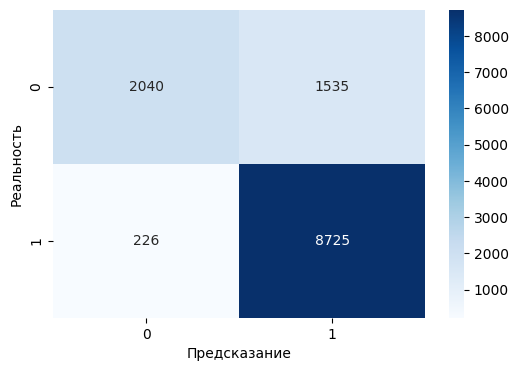

In [108]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

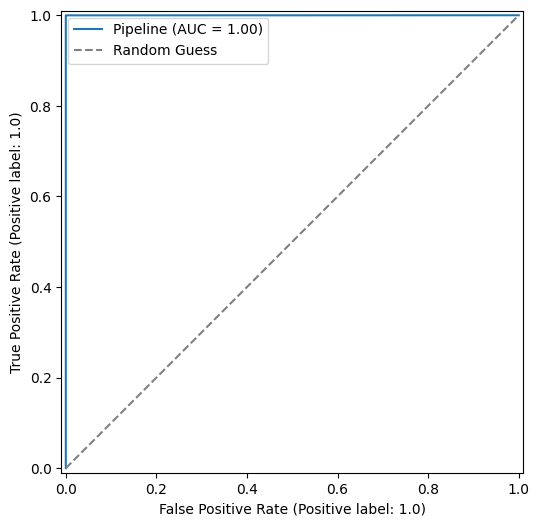

In [109]:
fig, ax = plt.subplots(figsize=(8, 6))
models["KNN"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["KNN"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

**SVM RBF**

In [110]:
best_params = study_svm_rbf.best_params

best_svm_rbf = Pipeline([
    ("scaler", StandardScaler()), 
    ("clf", SVC(kernel="rbf",**best_params))
])

best_svm_rbf.fit(X_train_balanced, y_train_balanced)

y_pred_svm_rbf = best_svm_rbf.predict(X_test)

In [111]:
print(classification_report(y_test, y_pred_svm_rbf))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3575
         1.0       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



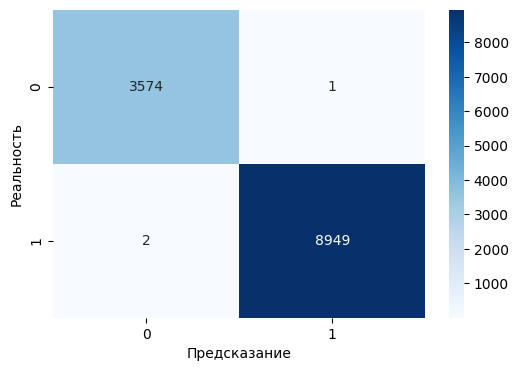

In [112]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm_rbf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

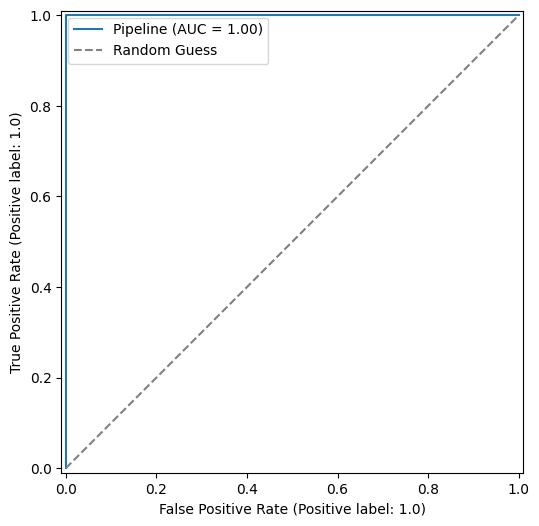

In [113]:
fig, ax = plt.subplots(figsize=(8, 6))
models["SVM (RBF Kernel)"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["SVM (RBF Kernel)"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

**SVM Sigmoid**

In [114]:
best_params = study_svm_rbf.best_params

best_svm_sigmoid = Pipeline([
    ("scaler", StandardScaler()), 
    ("clf", SVC(kernel="sigmoid",**best_params))
])

best_svm_sigmoid.fit(X_train_balanced, y_train_balanced)

y_pred_svm_sigmoid = best_svm_sigmoid.predict(X_test)

In [115]:
print(classification_report(y_test, y_pred_svm_sigmoid))

              precision    recall  f1-score   support

         0.0       0.68      0.85      0.75      3575
         1.0       0.93      0.84      0.88      8951

    accuracy                           0.84     12526
   macro avg       0.81      0.84      0.82     12526
weighted avg       0.86      0.84      0.85     12526



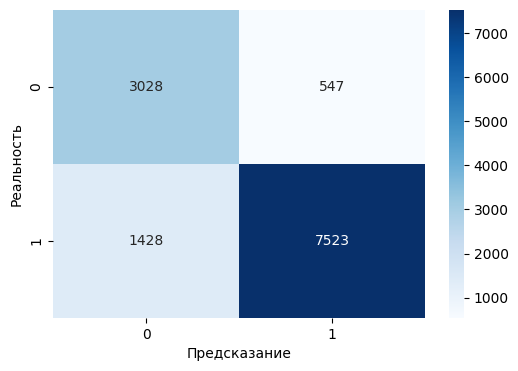

In [116]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm_sigmoid), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

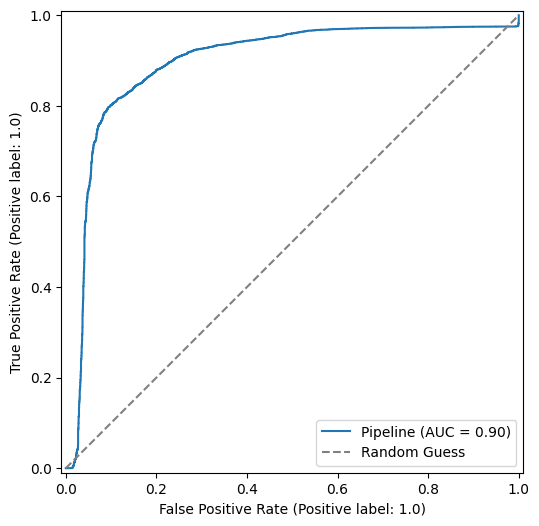

In [117]:
fig, ax = plt.subplots(figsize=(8, 6))
models["SVM (Sigmoid Kernel)"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["SVM (Sigmoid Kernel)"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

**SVM Polynomial**

In [118]:
best_params = study_svm_poly.best_params

best_svm_poly = Pipeline([
    ("scaler", StandardScaler()), 
    ("clf", SVC(kernel='poly',**best_params))
])

best_svm_poly.fit(X_train_balanced, y_train_balanced)

y_pred_svm_poly = best_svm_poly.predict(X_test)

In [119]:
print(classification_report(y_test, y_pred_svm_poly))

              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97      3575
         1.0       1.00      0.98      0.99      8951

    accuracy                           0.98     12526
   macro avg       0.97      0.99      0.98     12526
weighted avg       0.98      0.98      0.98     12526



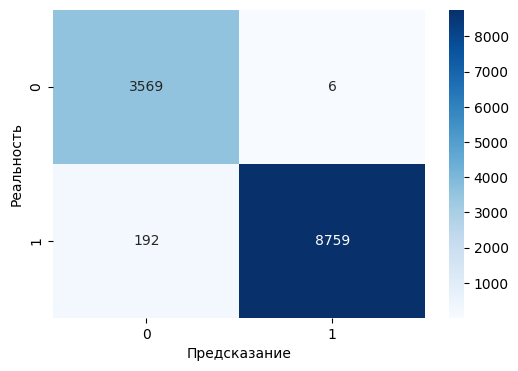

In [120]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm_poly), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

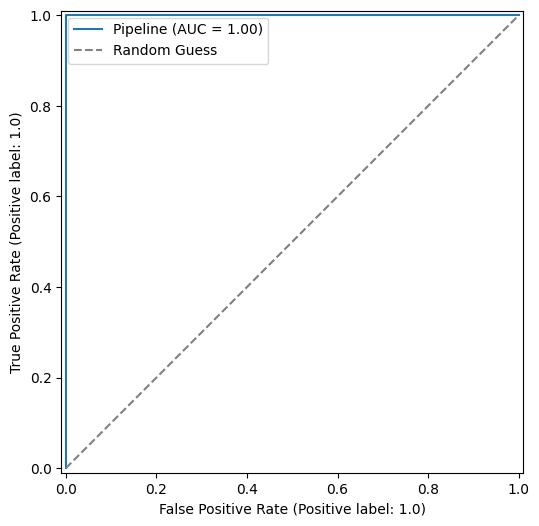

In [121]:
fig, ax = plt.subplots(figsize=(8, 6))
models["SVM (Polynomial Kernel)"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["SVM (Polynomial Kernel)"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

**SVM Linear**

In [122]:
best_params = study_svm.best_params

best_svm = Pipeline([
    ("scaler", StandardScaler()), 
    ("clf", SVC(kernel='linear',**best_params))
])

best_svm.fit(X_train_balanced, y_train_balanced)

y_pred_svm = best_svm.predict(X_test)

In [123]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      3575
         1.0       1.00      0.99      0.99      8951

    accuracy                           0.99     12526
   macro avg       0.98      0.99      0.99     12526
weighted avg       0.99      0.99      0.99     12526



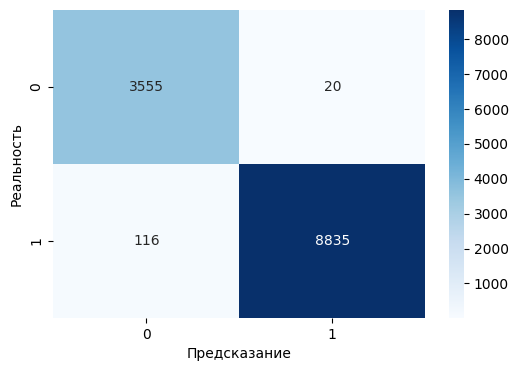

In [124]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

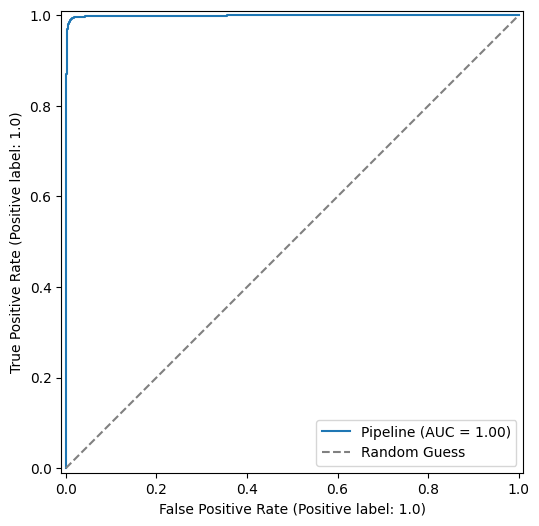

In [125]:
fig, ax = plt.subplots(figsize=(8, 6))
models["SVM (Linear Kernel)"].fit(X_train_balanced, y_train_balanced)
RocCurveDisplay.from_estimator(models["SVM (Linear Kernel)"], X_test, y_test, ax=ax)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.legend()
plt.show()

## Реализация метрик

In [9]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score
)

In [10]:
def custom_confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])

In [11]:
def custom_metrics(y_true, y_pred):
    cm = custom_confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return accuracy, precision, recall, f1

In [12]:
def custom_roc_auc(y_true, y_prob):
    pos = y_prob[y_true == 1]
    neg = y_prob[y_true == 0]
    
    match = 0
    for p in pos:
        for n in neg:
            if p > n:
                match += 1
            elif p == n:
                match += 0.5
                
    return match / (len(pos) * len(neg))

**Сравнение**

In [130]:
custom_confusion_matrix(y_test, y_pred_knn)

array([[3574,    1],
       [   4, 8947]])

In [131]:
confusion_matrix(y_test, y_pred_knn)

array([[3574,    1],
       [   4, 8947]])

In [132]:
custom_metrics(y_test, y_pred_knn)

(np.float64(0.9996008302730321),
 np.float64(0.9998882431828342),
 np.float64(0.9995531225561389),
 np.float64(0.9997206547851835))

In [133]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_knn)}")
print(f"Precision: {precision_score(y_test, y_pred_knn)}")
print(f"Recall:    {recall_score(y_test, y_pred_knn)}")
print(f"F1-Score:  {f1_score(y_test, y_pred_knn)}")

Accuracy:  0.9996008302730321
Precision: 0.9998882431828342
Recall:    0.9995531225561389
F1-Score:  0.9997206547851836


In [134]:
custom_roc_auc(y_test, y_pred_knn)

0.9996367011382093

In [135]:
print(roc_auc_score(y_test, y_pred_knn))

0.9996367011382093


## Реализация KNN

In [5]:
from custom_knn import CustomKNN

In [6]:
custom_knn = CustomKNN(k=5, metric="manhattan")

In [7]:
custom_knn.fit(X_train_balanced, y_train_balanced)

In [8]:
y_pred = custom_knn.predict(X_test)

In [13]:
custom_confusion_matrix(y_test, y_pred)

array([[3575,    0],
       [   3, 8948]])

In [14]:
custom_metrics(y_test, y_pred)

(np.float64(0.9997604981638193),
 np.float64(1.0),
 np.float64(0.9996648419171043),
 np.float64(0.9998323928711101))

## Вывод

Все модели показали хорошие метрики, особенно KNN и SVM с ядрами RBF и Polynomial. Их точность почти равна 1.

После подбора гиперпараметров результаты лишь немного улучшись, модели по умолчанию были настроены неплохо.

Дольше всего подбирались гиперпараметры для SVM на сигмоиде и полиномиальном ядре, причём сигмоид в итоге выдал относительно слабый результат. Как и Naive Bayes. 

KNN при этом обучался быстро и попал в число лидеров, так что для этой задачи он выглядит самым удачным выбором.